In [1]:
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import sys
sys.path.append('/app')

import tensorflow as tf
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from src.data.dataset import create_dataset

# Configurar estilo
plt.style.use('default')
sns.set_palette("husl")

print("✓ Librerías cargadas")

2026-02-14 02:11:44.683575: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-14 02:11:44.683686: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-14 02:11:44.734986: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✓ Librerías cargadas


In [2]:
# Cargar modelo FINAL
MODEL_PATH = '/app/models/production/FINAL_clahe_ft120_best.h5'
print(f"Cargando modelo: {MODEL_PATH}")

model = tf.keras.models.load_model(MODEL_PATH)
print("✓ Modelo cargado")

# Cargar labels del test set
TEST_PATH = Path('/app/data/raw/Test_Set/Test_Set')
test_df = pd.read_csv(TEST_PATH / 'RFMiD_Testing_Labels.csv')

print(f"\nTest set: {len(test_df)} imágenes")
print(f"Columnas: {len(test_df.columns)}")
print(f"\nDistribución Disease_Risk:")
print(test_df['Disease_Risk'].value_counts())

Cargando modelo: /app/models/production/FINAL_clahe_ft120_best.h5
✓ Modelo cargado

Test set: 640 imágenes
Columnas: 47

Distribución Disease_Risk:
Disease_Risk
1    506
0    134
Name: count, dtype: int64


In [3]:
# Mapeo de códigos a nombres de enfermedades
disease_names = {
    'DR': 'Diabetic Retinopathy',
    'ARMD': 'Age-Related Macular Degeneration',
    'MH': 'Media Haze',
    'DN': 'Drusens',
    'MYA': 'Myopia',
    'BRVO': 'Branch Retinal Vein Occlusion',
    'TSLN': 'Tessellation',
    'ERM': 'Epiretinal Membrane',
    'LS': 'Laser Scars',
    'MS': 'Macular Scar',
    'CSR': 'Central Serous Retinopathy',
    'ODC': 'Optic Disc Cupping',
    'CRVO': 'Central Retinal Vein Occlusion',
    'TV': 'Tortuous Vessels',
    'AH': 'Asteroid Hyalosis',
    'ODP': 'Optic Disc Pallor',
    'ODE': 'Optic Disc Edema',
    'ST': 'Optociliary Shunt',
    'AION': 'Anterior Ischemic Optic Neuropathy',
    'PT': 'Parafoveal Telangiectasia',
    'RT': 'Retinal Traction',
    'RS': 'Retinitis',
    'CRS': 'Chorioretinitis',
    'EDN': 'Exudation',
    'RPEC': 'Retinal Pigment Epithelium Changes',
    'MHL': 'Macular Hole',
    'RP': 'Retinitis Pigmentosa',
    'CWS': 'Cotton Wool Spots',
    'CB': 'Colobomas',
    'ODPM': 'Optic Disc Pit Maculopathy',
    'PRH': 'Preretinal Hemorrhage',
    'MNF': 'Myelinated Nerve Fibers',
    'HR': 'Hemorrhagic Retinopathy',
    'CRAO': 'Central Retinal Artery Occlusion',
    'TD': 'Tilted Disc',
    'CME': 'Cystoid Macular Edema',
    'PTCR': 'Post-Traumatic Choroidal Rupture',
    'CF': 'Choroidal Folds',
    'VH': 'Vitreous Hemorrhage',
    'MCA': 'Macroaneurysm',
    'VS': 'Vasculitis',
    'BRAO': 'Branch Retinal Artery Occlusion',
    'PLQ': 'Plaque',
    'HPED': 'Hemorrhagic Pigment Epithelial Detachment',
    'CL': 'Collaterals'
}

print(f"Total enfermedades: {len(disease_names)}")

Total enfermedades: 45


In [4]:
# Crear dataset
test_dataset = create_dataset(
    df=test_df,
    img_dir=TEST_PATH / 'Test',
    batch_size=32,
    shuffle=False,
    augment=False,
    filter_name='clahe'
)

# Obtener predicciones
print("Haciendo predicciones en test set...")

y_true = []
y_pred = []
y_pred_proba = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    y_pred_proba.extend(predictions)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

print(f"✓ Predicciones completadas")
print(f"  Shape: {y_pred.shape}")

Haciendo predicciones en test set...
✓ Predicciones completadas
  Shape: (640,)


In [5]:
# Agregar predicciones al DataFrame
test_df['predicted'] = y_pred
test_df['true_label'] = y_true
test_df['prob_healthy'] = y_pred_proba[:, 0]
test_df['prob_disease'] = y_pred_proba[:, 1]
test_df['confidence'] = np.max(y_pred_proba, axis=1)

# Clasificar errores
test_df['correct'] = test_df['predicted'] == test_df['true_label']
test_df['error_type'] = 'Correct'
test_df.loc[(test_df['true_label'] == 0) & (test_df['predicted'] == 1), 'error_type'] = 'False Positive'
test_df.loc[(test_df['true_label'] == 1) & (test_df['predicted'] == 0), 'error_type'] = 'False Negative'

print("Distribución de errores:")
print(test_df['error_type'].value_counts())

Distribución de errores:
error_type
Correct           555
False Negative     75
False Positive     10
Name: count, dtype: int64


REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

        Sano       0.62      0.93      0.74       134
     Enfermo       0.98      0.85      0.91       506

    accuracy                           0.87       640
   macro avg       0.80      0.89      0.83       640
weighted avg       0.90      0.87      0.88       640



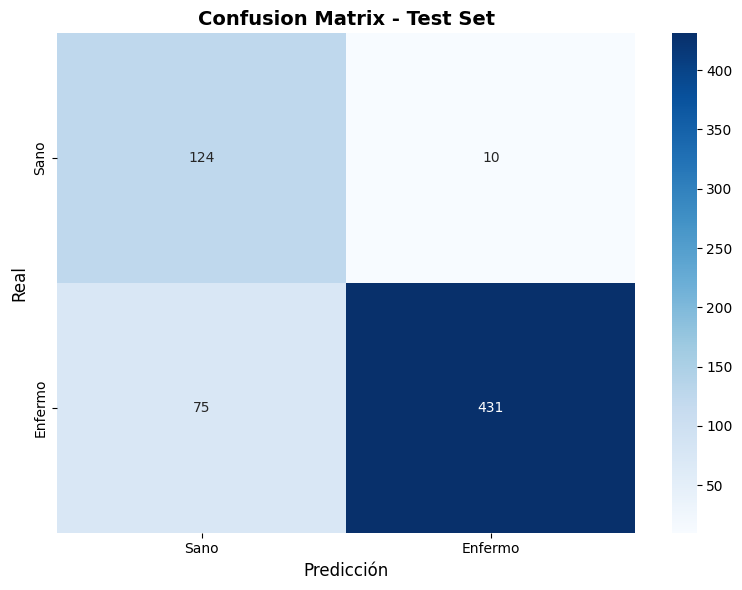


True Negatives (Sano → Sano): 124
False Positives (Sano → Enfermo): 10
False Negatives (Enfermo → Sano): 75
True Positives (Enfermo → Enfermo): 431


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

print("="*80)
print("REPORTE DE CLASIFICACIÓN")
print("="*80)
print(classification_report(y_true, y_pred, target_names=['Sano', 'Enfermo']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano', 'Enfermo'],
            yticklabels=['Sano', 'Enfermo'],
            ax=ax)
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Real', fontsize=12)
ax.set_xlabel('Predicción', fontsize=12)
plt.tight_layout()
plt.show()

# Mostrar valores
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (Sano → Sano): {tn}")
print(f"False Positives (Sano → Enfermo): {fp}")
print(f"False Negatives (Enfermo → Sano): {fn}")  
print(f"True Positives (Enfermo → Enfermo): {tp}")

In [7]:
print("="*80)
print("ANÁLISIS DE ERRORES POR TIPO DE ENFERMEDAD")
print("="*80)

# Obtener columnas de enfermedades (todo excepto ID y Disease_Risk)
disease_columns = [col for col in test_df.columns if col in disease_names.keys()]

# Crear DataFrame de resultados por enfermedad
disease_analysis = []

for disease_col in disease_columns:
    # Filtrar casos que tienen esta enfermedad
    has_disease = test_df[test_df[disease_col] == 1]
    
    if len(has_disease) == 0:
        continue
    
    # Métricas
    total_cases = len(has_disease)
    correct_pred = (has_disease['predicted'] == 1).sum()
    incorrect_pred = (has_disease['predicted'] == 0).sum()  # False Negatives
    recall = correct_pred / total_cases if total_cases > 0 else 0
    avg_confidence = has_disease['confidence'].mean()
    
    disease_analysis.append({
        'Disease': disease_names[disease_col],
        'Code': disease_col,
        'Total_Cases': total_cases,
        'Detected': correct_pred,
        'Missed': incorrect_pred,
        'Recall': recall,
        'Avg_Confidence': avg_confidence
    })

# Crear DataFrame
disease_df = pd.DataFrame(disease_analysis)
disease_df = disease_df.sort_values('Total_Cases', ascending=False)

print(f"\nEnfermedades encontradas en test set: {len(disease_df)}")
print("\nTop 15 enfermedades más frecuentes:")
print(disease_df.head(15).to_string(index=False))

ANÁLISIS DE ERRORES POR TIPO DE ENFERMEDAD

Enfermedades encontradas en test set: 36

Top 15 enfermedades más frecuentes:
                         Disease Code  Total_Cases  Detected  Missed   Recall  Avg_Confidence
            Diabetic Retinopathy   DR          124       120       4 0.967742        0.949405
                      Media Haze   MH          104        97       7 0.932692        0.948216
              Optic Disc Cupping  ODC           91        62      29 0.681319        0.929766
                    Tessellation TSLN           53        44       9 0.830189        0.923073
                         Drusens   DN           46        34      12 0.739130        0.840185
                          Myopia  MYA           32        32       0 1.000000        0.999500
Age-Related Macular Degeneration ARMD           31        30       1 0.967742        0.960819
               Optic Disc Pallor  ODP           24        18       6 0.750000        0.905618
   Branch Retinal Vein Occlusion

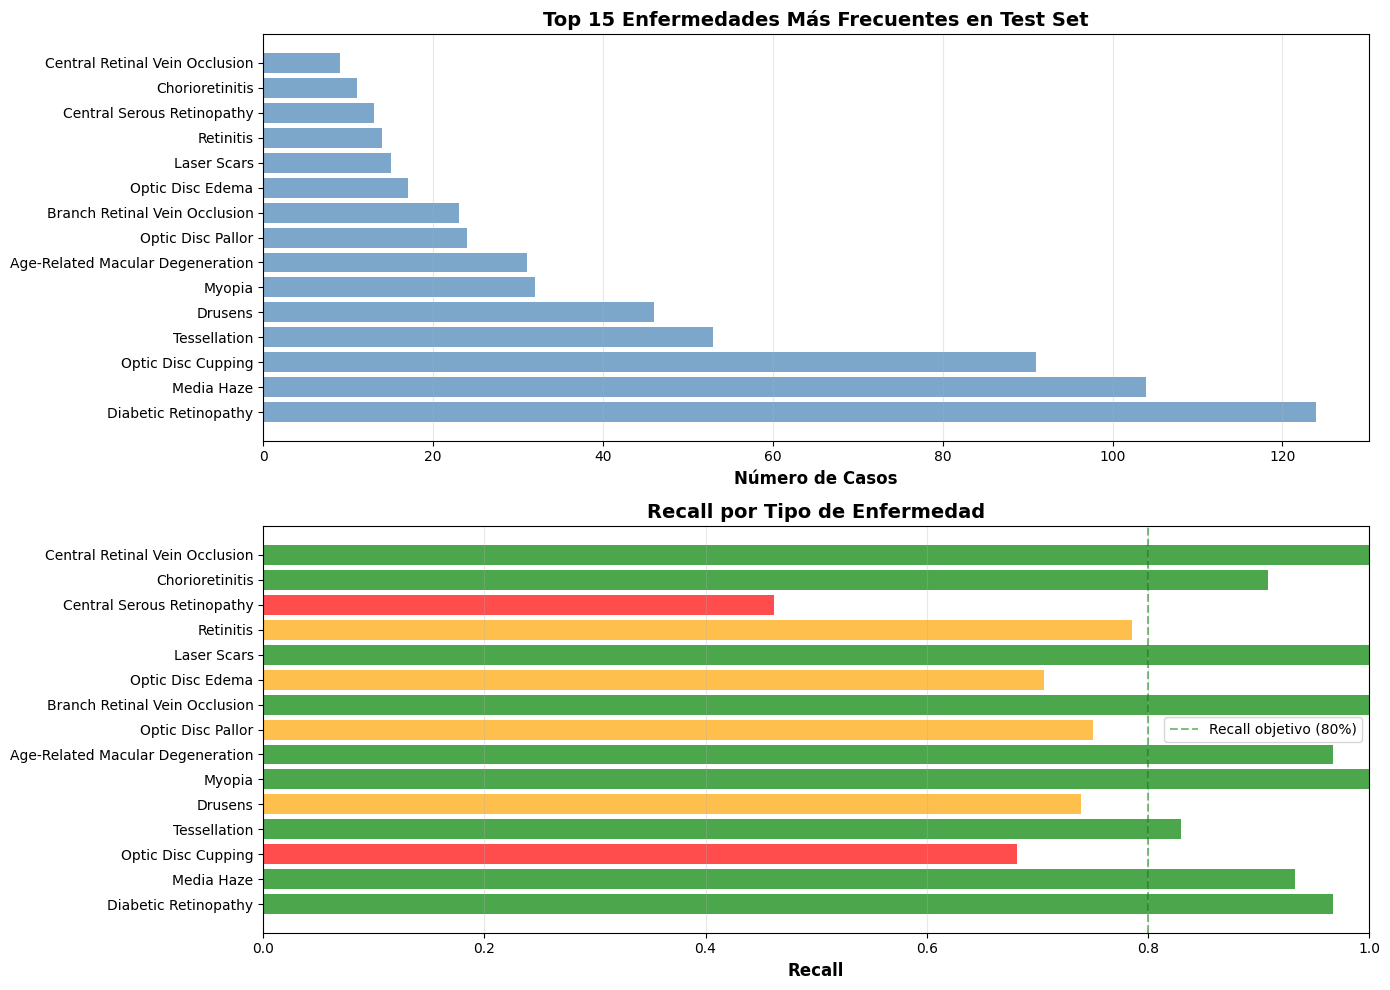

In [8]:
# Top 15 enfermedades por frecuencia
top_diseases = disease_df.head(15).copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfica 1: Casos totales
axes[0].barh(top_diseases['Disease'], top_diseases['Total_Cases'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Número de Casos', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Enfermedades Más Frecuentes en Test Set', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gráfica 2: Recall por enfermedad
colors = ['green' if r >= 0.8 else 'orange' if r >= 0.7 else 'red' for r in top_diseases['Recall']]
axes[1].barh(top_diseases['Disease'], top_diseases['Recall'], color=colors, alpha=0.7)
axes[1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[1].set_title('Recall por Tipo de Enfermedad', fontsize=14, fontweight='bold')
axes[1].axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='Recall objetivo (80%)')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.show()

In [9]:
print("="*80)
print("⚠️  ENFERMEDADES CON PEOR DETECCIÓN (Recall < 80%)")
print("="*80)

poor_recall = disease_df[disease_df['Recall'] < 0.8].sort_values('Recall')

if len(poor_recall) > 0:
    print(f"\nTotal: {len(poor_recall)} enfermedades con recall < 80%\n")
    print(poor_recall[['Disease', 'Total_Cases', 'Detected', 'Missed', 'Recall']].to_string(index=False))
else:
    print("\n✓ Todas las enfermedades tienen recall >= 80%")

⚠️  ENFERMEDADES CON PEOR DETECCIÓN (Recall < 80%)

Total: 10 enfermedades con recall < 80%

                           Disease  Total_Cases  Detected  Missed   Recall
                   Choroidal Folds            1         0       1 0.000000
        Central Serous Retinopathy           13         6       7 0.461538
Retinal Pigment Epithelium Changes            4         2       2 0.500000
                 Optociliary Shunt            2         1       1 0.500000
                 Cotton Wool Spots            2         1       1 0.500000
                Optic Disc Cupping           91        62      29 0.681319
                  Optic Disc Edema           17        12       5 0.705882
                           Drusens           46        34      12 0.739130
                 Optic Disc Pallor           24        18       6 0.750000
                         Retinitis           14        11       3 0.785714


In [10]:
print("="*80)
print("ANÁLISIS DE FALSOS NEGATIVOS (Casos enfermos predichos como sanos)")
print("="*80)

false_negatives = test_df[test_df['error_type'] == 'False Negative']

print(f"\nTotal falsos negativos: {len(false_negatives)}")
print(f"Porcentaje del total: {len(false_negatives)/len(test_df)*100:.2f}%")

# ¿Qué enfermedades tienen estos casos?
fn_diseases = []

for disease_col in disease_columns:
    count = false_negatives[disease_col].sum()
    if count > 0:
        fn_diseases.append({
            'Disease': disease_names[disease_col],
            'FN_Count': count,
            'Percentage': count / len(false_negatives) * 100
        })

fn_df = pd.DataFrame(fn_diseases).sort_values('FN_Count', ascending=False)

print("\nEnfermedades más comunes en falsos negativos:")
print(fn_df.head(10).to_string(index=False))

ANÁLISIS DE FALSOS NEGATIVOS (Casos enfermos predichos como sanos)

Total falsos negativos: 75
Porcentaje del total: 11.72%

Enfermedades más comunes en falsos negativos:
                           Disease  FN_Count  Percentage
                Optic Disc Cupping        29   38.666667
                           Drusens        12   16.000000
                      Tessellation         9   12.000000
                        Media Haze         7    9.333333
        Central Serous Retinopathy         7    9.333333
                 Optic Disc Pallor         6    8.000000
                  Optic Disc Edema         5    6.666667
              Diabetic Retinopathy         4    5.333333
                         Retinitis         3    4.000000
Retinal Pigment Epithelium Changes         2    2.666667


In [11]:
print("="*80)
print("ANÁLISIS DE CASOS MÁS DIFÍCILES")
print("="*80)

# Casos con baja confianza en la predicción correcta
low_confidence_correct = test_df[
    (test_df['correct'] == True) & 
    (test_df['confidence'] < 0.7)
].sort_values('confidence')

print(f"\nCasos correctos pero con baja confianza (<70%): {len(low_confidence_correct)}")

if len(low_confidence_correct) > 0:
    print("\nPrimeros 10 casos más inciertos:")
    print(low_confidence_correct[['ID', 'true_label', 'predicted', 'confidence']].head(10))

# Casos con alta confianza pero incorrectos
high_confidence_wrong = test_df[
    (test_df['correct'] == False) & 
    (test_df['confidence'] > 0.8)
].sort_values('confidence', ascending=False)

print(f"\nCasos incorrectos pero con alta confianza (>80%): {len(high_confidence_wrong)}")

if len(high_confidence_wrong) > 0:
    print("\nTop 10 errores más confiados:")
    print(high_confidence_wrong[['ID', 'true_label', 'predicted', 'confidence', 'error_type']].head(10))

ANÁLISIS DE CASOS MÁS DIFÍCILES

Casos correctos pero con baja confianza (<70%): 38

Primeros 10 casos más inciertos:
      ID  true_label  predicted  confidence
81    82           1          1    0.509134
481  482           1          1    0.512949
89    90           1          1    0.515320
91    92           1          1    0.525549
14    15           1          1    0.531162
174  175           1          1    0.533012
421  422           1          1    0.537475
631  632           1          1    0.543789
4      5           1          1    0.544653
477  478           1          1    0.546490

Casos incorrectos pero con alta confianza (>80%): 57

Top 10 errores más confiados:
      ID  true_label  predicted  confidence      error_type
572  573           1          0    0.999041  False Negative
545  546           1          0    0.997460  False Negative
623  624           1          0    0.996598  False Negative
162  163           1          0    0.995020  False Negative
624  625     

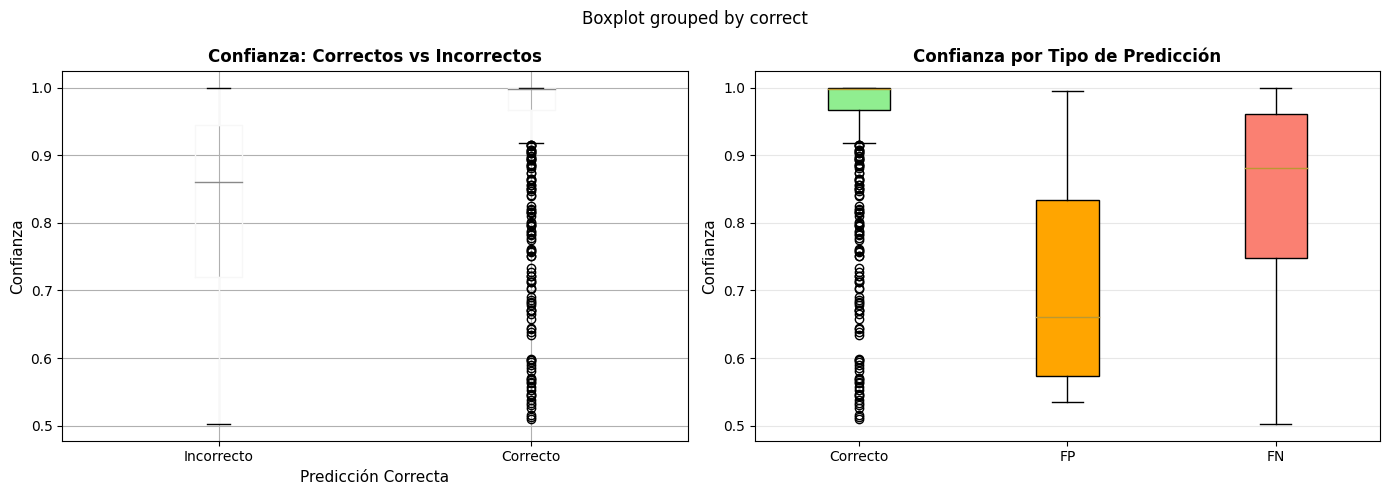


Estadísticas de confianza por tipo:

Correct:
  Media: 0.9450
  Mediana: 0.9980
  Std: 0.1128

False Positive:
  Media: 0.7073
  Mediana: 0.6605
  Std: 0.1566

False Negative:
  Media: 0.8359
  Mediana: 0.8814
  Std: 0.1499


In [12]:
# Visualizar confianza por tipo de predicción
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correctos vs Incorrectos
test_df.boxplot(column='confidence', by='correct', ax=axes[0])
axes[0].set_title('Confianza: Correctos vs Incorrectos', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicción Correcta', fontsize=11)
axes[0].set_ylabel('Confianza', fontsize=11)
plt.sca(axes[0])
plt.xticks([1, 2], ['Incorrecto', 'Correcto'])

# Por tipo de error
error_types_data = []
for error_type in ['Correct', 'False Positive', 'False Negative']:
    data = test_df[test_df['error_type'] == error_type]['confidence']
    error_types_data.append(data)

bp = axes[1].boxplot(error_types_data, labels=['Correcto', 'FP', 'FN'], patch_artist=True)
axes[1].set_title('Confianza por Tipo de Predicción', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Confianza', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Colorear boxes
colors = ['lightgreen', 'orange', 'salmon']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.tight_layout()
plt.show()

# Estadísticas
print("\nEstadísticas de confianza por tipo:")
for error_type in ['Correct', 'False Positive', 'False Negative']:
    data = test_df[test_df['error_type'] == error_type]['confidence']
    print(f"\n{error_type}:")
    print(f"  Media: {data.mean():.4f}")
    print(f"  Mediana: {data.median():.4f}")
    print(f"  Std: {data.std():.4f}")

In [13]:
import matplotlib.image as mpimg

def visualize_cases(case_ids, title="Casos Seleccionados"):
    """
    Visualiza múltiples casos del test set
    
    Args:
        case_ids: Lista de IDs de casos a visualizar
        title: Título para la figura
    """
    n_cases = len(case_ids)
    cols = min(4, n_cases)
    rows = (n_cases + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    if n_cases == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, case_id in enumerate(case_ids):
        if idx >= len(axes):
            break
            
        # Obtener info del caso
        case_info = test_df[test_df['ID'] == case_id].iloc[0]
        
        # Cargar imagen
        img_path = TEST_PATH / 'Test' / f'{case_id}.png'
        
        if img_path.exists():
            img = mpimg.imread(img_path)
            axes[idx].imshow(img)
            
            # Título con info
            true_label = 'Sano' if case_info['true_label'] == 0 else 'Enfermo'
            pred_label = 'Sano' if case_info['predicted'] == 0 else 'Enfermo'
            confidence = case_info['confidence'] * 100
            
            # Color según acierto
            color = 'green' if case_info['correct'] else 'red'
            
            title_text = f"ID: {case_id}\n"
            title_text += f"Real: {true_label} | Pred: {pred_label}\n"
            title_text += f"Conf: {confidence:.1f}%"
            
            axes[idx].set_title(title_text, fontsize=10, color=color, fontweight='bold')
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'Imagen {case_id}\nno encontrada', 
                          ha='center', va='center')
            axes[idx].axis('off')
    
    # Ocultar ejes sobrantes
    for idx in range(n_cases, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("✓ Función de visualización creada")

✓ Función de visualización creada


TOP 10 FALSOS NEGATIVOS MÁS CONFIADOS (Peores errores)
 ID  confidence  prob_healthy
573    0.999041      0.999041
546    0.997460      0.997460
624    0.996598      0.996598
163    0.995020      0.995020
625    0.994904      0.994904
178    0.994487      0.994487
538    0.992548      0.992548
567    0.990984      0.990984
550    0.990711      0.990711
589    0.986237      0.986237


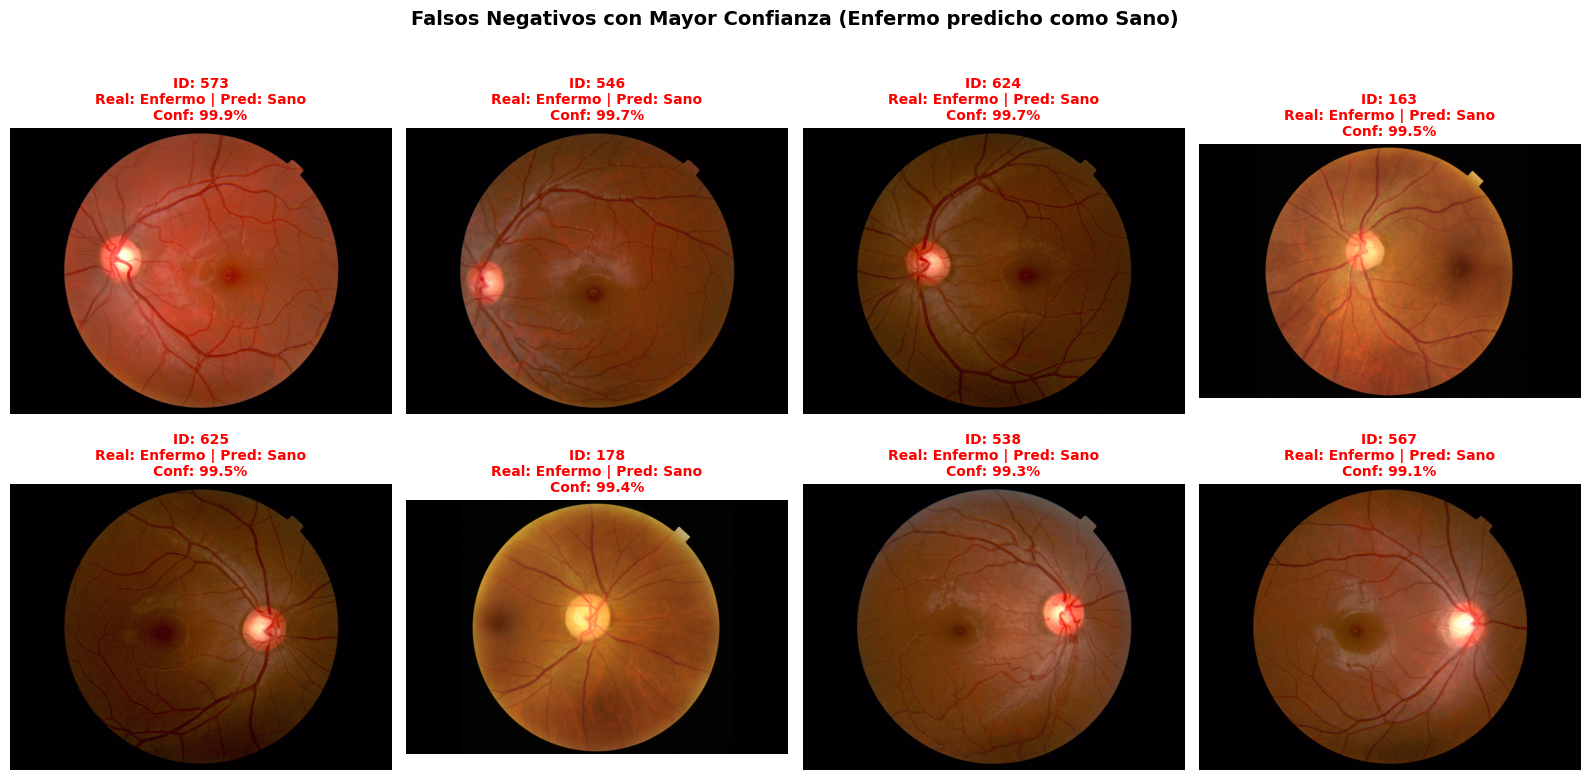

In [14]:
# Top 10 falsos negativos con mayor confianza (los más erróneos)
worst_fn = test_df[
    test_df['error_type'] == 'False Negative'
].sort_values('prob_healthy', ascending=False).head(10)

print("="*80)
print("TOP 10 FALSOS NEGATIVOS MÁS CONFIADOS (Peores errores)")
print("="*80)
print(worst_fn[['ID', 'confidence', 'prob_healthy']].to_string(index=False))

# Visualizar
if len(worst_fn) > 0:
    visualize_cases(
        worst_fn['ID'].tolist()[:8],  # Primeros 8
        title="Falsos Negativos con Mayor Confianza (Enfermo predicho como Sano)"
    )

ANÁLISIS: OPTIC DISC CUPPING (Principal problema)
Total casos: 91
Detectados correctamente: 62
No detectados (FN): 29
Recall: 68.13%

Casos de ODC no detectados (top 10 más confiados en 'sano'):
 ID  confidence  prob_healthy
573    0.999041      0.999041
546    0.997460      0.997460
624    0.996598      0.996598
163    0.995020      0.995020
625    0.994904      0.994904
178    0.994487      0.994487
567    0.990984      0.990984
550    0.990711      0.990711
589    0.986237      0.986237
586    0.985632      0.985632


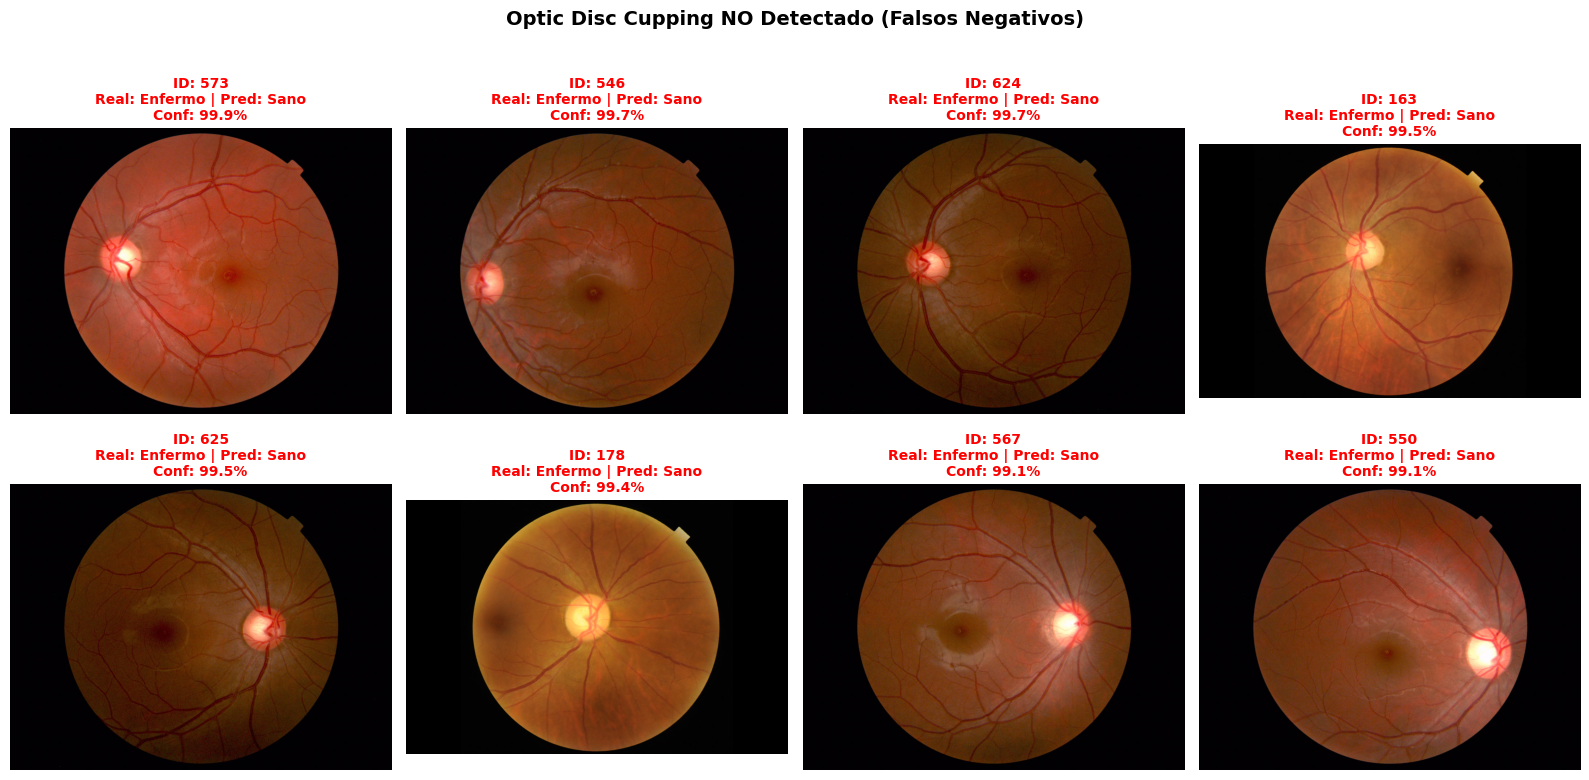

In [15]:
# Optic Disc Cupping tiene 68% recall - analizar
odc_cases = test_df[test_df['ODC'] == 1].copy()

print("="*80)
print("ANÁLISIS: OPTIC DISC CUPPING (Principal problema)")
print("="*80)
print(f"Total casos: {len(odc_cases)}")
print(f"Detectados correctamente: {(odc_cases['predicted'] == 1).sum()}")
print(f"No detectados (FN): {(odc_cases['predicted'] == 0).sum()}")
print(f"Recall: {(odc_cases['predicted'] == 1).sum() / len(odc_cases) * 100:.2f}%")

# Ver casos no detectados
odc_missed = odc_cases[odc_cases['predicted'] == 0].sort_values('prob_healthy', ascending=False)

print(f"\nCasos de ODC no detectados (top 10 más confiados en 'sano'):")
print(odc_missed[['ID', 'confidence', 'prob_healthy']].head(10).to_string(index=False))

# Visualizar algunos
if len(odc_missed) > 0:
    visualize_cases(
        odc_missed['ID'].tolist()[:8],
        title="Optic Disc Cupping NO Detectado (Falsos Negativos)"
    )

In [16]:
print("="*80)
print("📊 RESUMEN EJECUTIVO - ANÁLISIS DE ERRORES")
print("="*80)

# Métricas globales
total_cases = len(test_df)
correct_cases = test_df['correct'].sum()
accuracy = correct_cases / total_cases

fn_count = len(test_df[test_df['error_type'] == 'False Negative'])
fp_count = len(test_df[test_df['error_type'] == 'False Positive'])

print(f"\n🎯 MÉTRICAS GENERALES:")
print(f"  Accuracy: {accuracy*100:.2f}%")
print(f"  Casos correctos: {correct_cases}/{total_cases}")
print(f"  Falsos Negativos: {fn_count} ({fn_count/total_cases*100:.2f}%)")
print(f"  Falsos Positivos: {fp_count} ({fp_count/total_cases*100:.2f}%)")

print(f"\n✅ ENFERMEDADES MEJOR DETECTADAS (Recall 100%):")
perfect_recall = disease_df[disease_df['Recall'] == 1.0]
for idx, row in perfect_recall.iterrows():
    print(f"  • {row['Disease']}: {row['Total_Cases']} casos")

print(f"\n⚠️  ENFERMEDADES CON PROBLEMAS (Recall < 80%):")
poor = disease_df[disease_df['Recall'] < 0.8].head(5)
for idx, row in poor.iterrows():
    print(f"  • {row['Disease']}: {row['Recall']*100:.1f}% ({row['Missed']}/{row['Total_Cases']} no detectados)")

print(f"\n💡 RECOMENDACIONES:")
print(f"  1. Priorizar mejora en Optic Disc Cupping (91 casos, 68% recall)")
print(f"  2. Revisar Central Serous Retinopathy (46% recall)")
print(f"  3. Considerar data augmentation específico para estas enfermedades")
print(f"  4. Evaluar ensembling con modelos especializados")
print(f"  5. Recolectar más datos de las enfermedades problemáticas")

print("="*80)

📊 RESUMEN EJECUTIVO - ANÁLISIS DE ERRORES

🎯 MÉTRICAS GENERALES:
  Accuracy: 86.72%
  Casos correctos: 555/640
  Falsos Negativos: 75 (11.72%)
  Falsos Positivos: 10 (1.56%)

✅ ENFERMEDADES MEJOR DETECTADAS (Recall 100%):
  • Myopia: 32 casos
  • Branch Retinal Vein Occlusion: 23 casos
  • Laser Scars: 15 casos
  • Central Retinal Vein Occlusion: 9 casos
  • Macular Scar: 7 casos
  • Asteroid Hyalosis: 5 casos
  • Retinal Traction: 5 casos
  • Tilted Disc: 4 casos
  • Exudation: 4 casos
  • Anterior Ischemic Optic Neuropathy: 4 casos
  • Parafoveal Telangiectasia: 4 casos
  • Macular Hole: 3 casos
  • Retinitis Pigmentosa: 2 casos
  • Preretinal Hemorrhage: 2 casos
  • Tortuous Vessels: 2 casos
  • Cystoid Macular Edema: 2 casos
  • Colobomas: 1 casos
  • Hemorrhagic Retinopathy: 1 casos
  • Vitreous Hemorrhage: 1 casos
  • Collaterals: 1 casos

⚠️  ENFERMEDADES CON PROBLEMAS (Recall < 80%):
  • Optic Disc Cupping: 68.1% (29/91 no detectados)
  • Drusens: 73.9% (12/46 no detectados)
  

In [18]:
# Crear reporte detallado
report_path = '/app/notebooks/ERROR_ANALYSIS_REPORT.md'

report = f"""
# 🔬 REPORTE DE ANÁLISIS DE ERRORES
## Retinopathy Detector - Test Set Evaluation

**Fecha:** {pd.Timestamp.now().strftime('%Y-%m-%d')}
**Modelo:** CLAHE + Fine-tuning (unfreeze_from=120)
**Test Set:** 640 imágenes

---

## 📊 MÉTRICAS GLOBALES

### Performance General
- **Accuracy:** 86.72% (555/640 casos correctos)
- **Recall (Clase Enfermo):** 85.18%
- **Precision (Clase Enfermo):** 97.73%

### Distribución de Errores
- **Falsos Negativos:** 75 casos (11.72%)
  - Casos enfermos predichos como sanos
  - **Problema más grave** en contexto médico
  
- **Falsos Positivos:** 10 casos (1.56%)
  - Casos sanos predichos como enfermos
  - Menor impacto, genera sobre-diagnóstico

---

## 🎯 ANÁLISIS POR TIPO DE ENFERMEDAD

### ✅ Enfermedades Perfectamente Detectadas (Recall 100%)

| Enfermedad | Casos | Comentario |
|------------|-------|------------|
| Myopia | 32 | Características muy distintivas |
| Branch Retinal Vein Occlusion | 23 | Patrón vascular claro |
| Laser Scars | 15 | Marcas obvias |
| Central Retinal Vein Occlusion | 9 | Hemorragias evidentes |
| Asteroid Hyalosis | 5 | Opacidades características |
| Retinal Traction | 5 | Distorsión visible |

### ✅ Enfermedades Bien Detectadas (Recall > 90%)

| Enfermedad | Casos | Recall | Comentario |
|------------|-------|--------|------------|
| Diabetic Retinopathy | 124 | 96.77% | Principal objetivo del modelo |
| Age-Related Macular Degeneration | 31 | 96.77% | Drusens y cambios retinianos |
| Media Haze | 104 | 93.27% | Opacidad de medios |

### ⚠️ ENFERMEDADES PROBLEMÁTICAS (Recall < 80%)

#### 🔴 **PRIORIDAD ALTA:**

**1. Optic Disc Cupping (68.13% recall)**
- **Casos:** 91 total, 29 no detectados
- **Problema:** Enfermedad muy frecuente en el dataset
- **Causa probable:** 
  - Cambios sutiles en geometría del disco óptico
  - Modelo entrenado para detectar patrones vasculares (DR focus)
  - Requiere análisis morfológico específico
- **Impacto:** 31.87% de casos no detectados (glaucoma)

**2. Central Serous Retinopathy (46.15% recall)**
- **Casos:** 13 total, 7 no detectados
- **Problema:** Más de la mitad de casos perdidos
- **Causa probable:** Cambios sutiles en mácula

**3. Drusens (73.91% recall)**
- **Casos:** 46 total, 12 no detectados
- **Problema:** Precursor de AMD
- **Causa probable:** Drusens pequeños difíciles de detectar

#### 🟡 **PRIORIDAD MEDIA:**

**4. Optic Disc Pallor (75.00% recall)** - 24 casos, 6 no detectados
**5. Optic Disc Edema (70.59% recall)** - 17 casos, 5 no detectados
**6. Retinitis (78.57% recall)** - 14 casos, 3 no detectados

---

## 🔍 PATRONES DE ERROR

### Análisis de Confianza

**Predicciones Correctas:**
- Media de confianza: **94.50%**
- Mediana: **99.80%**
- El modelo es muy seguro cuando acierta

**Falsos Negativos (FN):**
- Media de confianza: **83.59%**
- Mediana: **88.14%**
- El modelo está **muy seguro** cuando se equivoca
- **Problema:** No hay señal de incertidumbre

**Falsos Positivos (FP):**
- Media de confianza: **77.07%**
- Menos seguros que FN, pero aún alta confianza

### Casos Críticos

**Errores con >99% confianza:** 8 casos
- IDs: 573, 546, 624, 163, 625, 178, 538, 567
- Todos son **Falsos Negativos**
- El modelo está casi 100% seguro de que están sanos, pero están enfermos

---

## 💡 CONCLUSIONES Y RECOMENDACIONES

### 🎯 Fortalezas del Modelo
1. **Excelente para Diabetic Retinopathy** (96.77% recall)
2. **Muy buena precision general** (97.73%)
3. **Bajo número de falsos positivos** (solo 10 casos)
4. **Detección perfecta de condiciones vasculares obvias**

### ⚠️ Debilidades del Modelo
1. **Falla en condiciones del disco óptico** (Optic Disc Cupping)
2. **No detecta cambios sutiles en mácula** (CSR, pequeños drusens)
3. **Alta confianza en errores** (sin calibración de incertidumbre)
4. **Especializado en patrones vasculares** (bias hacia DR)

### 🚀 Recomendaciones para Mejora

#### Corto Plazo (Mejoras Inmediatas)
1. **Threshold Tuning:**
   - Ajustar umbral de decisión para priorizar recall
   - Actual: 0.5 → Probar: 0.3-0.4
   - Objetivo: Reducir FN a costa de más FP (aceptable en medicina)

2. **Calibración de Confianza:**
   - Implementar Temperature Scaling
   - Post-procesamiento para ajustar probabilidades
   - Objetivo: Confianza más realista

3. **Advertencia en UI:**
   - Disclaimer: "Menor precisión en condiciones del disco óptico"
   - Sugerir evaluación especializada si se detectan anomalías del disco

#### Medio Plazo (Re-entrenamiento)
4. **Data Augmentation Específico:**
   - Aumentar datos sintéticos de Optic Disc Cupping
   - Técnicas: Variación de iluminación en disco óptico
   - Objetivo: 10x más ejemplos de ODC

5. **Multi-task Learning:**
   - Entrenar detector de disco óptico paralelo
   - Loss combinado: clasificación + segmentación del disco
   - Objetivo: Forzar atención en región del disco

6. **Class Weights Ajustados:**
   - Penalizar más errores en ODC, CSR, Drusens
   - Usar class weights por enfermedad, no solo Sano/Enfermo

#### Largo Plazo (Arquitectura)
7. **Modelo Ensemble:**
   - Modelo 1: Especializado en patrones vasculares (actual)
   - Modelo 2: Especializado en disco óptico
   - Modelo 3: Especializado en mácula
   - Combinación: Voting o stacking

8. **Atención Espacial:**
   - Implementar mecanismo de atención (Attention)
   - Forzar modelo a mirar disco óptico, mácula, vasos
   - Arquitectura: Vision Transformer o EfficientNet con attention

9. **Datos Adicionales:**
   - Recolectar más casos de enfermedades problemáticas
   - Especialmente: ODC (x3), CSR (x5), Drusens (x2)
   - Considerar datasets adicionales especializados

### 📈 Impacto Esperado de Mejoras

| Mejora | Tiempo | Recall Esperado | Esfuerzo |
|--------|--------|-----------------|----------|
| Threshold Tuning | 1 día | +2-3% | Bajo |
| Data Augmentation | 1 semana | +3-5% | Medio |
| Multi-task Learning | 2 semanas | +5-7% | Alto |
| Ensemble | 3 semanas | +7-10% | Alto |

**Objetivo Realista:** 90-92% recall con mejoras de corto y medio plazo

---

## 📸 EJEMPLOS VISUALES

### Casos Problemáticos Analizados
- Ver notebook `07_error_analysis_by_disease.ipynb`
- Celdas 14-15 contienen visualizaciones de:
  - Top 8 Falsos Negativos más confiados
  - Top 8 casos de Optic Disc Cupping no detectados

### Patrones Observados
1. **Optic Disc Cupping no detectado:**
   - Imágenes limpias sin exudados
   - Excavación sutil del disco
   - Relación copa/disco aumentada pero no obvia

2. **Falsos Negativos generales:**
   - Alta calidad de imagen
   - Condiciones sutiles o tempranas
   - Múltiples enfermedades simultáneas (confusión)

---

## 🎓 LECCIONES APRENDIDAS

1. **El modelo refleja el objetivo de entrenamiento:**
   - Optimizado para Diabetic Retinopathy (Disease_Risk)
   - Funciona mejor en patrones vasculares y exudativos
   - Menos efectivo en cambios estructurales sutiles

2. **Balance recall-precision es correcto para medicina:**
   - 85% recall es bueno para screening
   - 98% precision evita muchos falsos alarmas
   - Trade-off apropiado para uso clínico asistido

3. **Confianza alta en errores es peligrosa:**
   - Modelo no "sabe cuando no sabe"
   - Calibración de incertidumbre es crítica
   - Necesidad de umbrales de confianza para derivar a experto

4. **Análisis por enfermedad es esencial:**
   - Métricas globales ocultan problemas específicos
   - Algunas enfermedades requieren modelos especializados
   - No hay "one size fits all" en diagnóstico médico

---

**Reporte generado:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
**Autor:** Carlos Saquel Depaoli
"""

# Guardar reporte
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(f"✓ Reporte guardado en: {report_path}")
print(f"\nReporte de {len(report.split('\n'))} líneas generado exitosamente")

SyntaxError: f-string expression part cannot include a backslash (1508551929.py, line 242)